In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# define file paths 
RAW_TWEET_PATH = "../data/raw/raw_tweets.csv"
TWEET_PATH = "../data/processed/clean_tweets.csv"
MODEL_TABLE_PATH = "../data/results/modelling_table.csv"
MNLG_TABLE_PATH = "../data/results/mn_logreg_evaluation.csv"
RF_TABLE_PATH = "../data/results/rf_evaluation.csv"

# load datasets 
raw_df = pd.read_csv(RAW_TWEET_PATH)
model_df = pd.read_csv(MODEL_TABLE_PATH, index_col="date")  # main modelling table with sentiment and returns
mnlg_df = pd.read_csv(MNLG_TABLE_PATH)  # multinomial logistic regression evaluation metrics
rf_df = pd.read_csv(RF_TABLE_PATH)  # random forest evaluation metrics
tweet_df = pd.read_csv(TWEET_PATH) # scored tweets

## Exploratory Data Analysis 
This notebook will explore the modelling table of financial and social data to explore its relationships and patterns

### Cleaning QA

In [14]:
display(pd.concat([raw_df[["text"]].head(), tweet_df[["text"]].head()]))

,text
0,@KennyDegu very very little volume. With $10T ...
1,#ES_F achieved Target 2780 closing above 50% #...
2,RT @KimbleCharting: Silver/Gold indicator crea...
3,@Issaquahfunds Hedged our $MSFT position into ...
4,RT @zipillinois: 3 Surprisingly Controversial ...
0,very very little volume with $10t you d think ...
1,es_f achieved target 2780 closing above 50% fi...
2,rt silver gold indicator creates one of the la...
3,hedged our $msft position into close seemed to...
4,rt 3 surprisingly controversial stocks in dona...


### Sentiment Scoring QA
Select 100 random tweets containing the word "grow" and 100 containing "fall" and compute average sentiment scores in order to assess the quality of scores 

In [15]:
pos_df = tweet_df.loc[tweet_df["text"].str.contains("grow", na=False)]

test_df = pos_df.sample(100)
display (test_df.head())

mean_score = test_df["fb_score"].mean()

print(f"Arithmetic Mean finBERT score of results: {mean_score}")

,timestamp,text,fb_score
672246,2020-06-27 16:07:23+00:00,in q1 2020 ending march $amzn s fastest growin...,0.858508
100770,2020-04-17 13:11:49+00:00,bye bye buybacks buybacks are expected to fall...,-0.959336
682698,2020-06-28 07:24:57+00:00,rt earnings growth rate % among largest financ...,0.686061
643033,2020-06-25 17:55:06+00:00,nice work actually cannabis lending banking wo...,0.684561
855317,2020-07-12 04:31:12+00:00,rt dealbuy update this list aged well $enph $t...,-0.002591


Arithmetic Mean finBERT score of results: 0.21123193448409439


In [16]:
neg_df = tweet_df[tweet_df["text"].str.contains("fall", na=False)]

test_df = neg_df.sample(100)
display(test_df.head())

mean_score = test_df["fb_score"].mean()

print(f"Arithmetic Mean finBERT score of results: {mean_score}")

,timestamp,text,fb_score
819289,2020-07-09 12:45:01+00:00,$cznc we have detected a noticeable fall in th...,-0.927132
248106,2020-04-29 09:26:04+00:00,why do i expect markets to fall further that s...,-0.946980
229283,2020-04-28 12:09:19+00:00,rt $spx has now retraced 57% of the 35% fall w...,-0.920845
611464,2020-06-23 19:22:22+00:00,spx500 is dangerous a new fall is coming spx f...,-0.597296
540243,2020-06-16 00:55:03+00:00,asia open stocks the usfed s commitment to buy...,0.669878


Arithmetic Mean finBERT score of results: -0.3867509308457375


### Modelling Table Visualizations

#### Time Series of Sentiment Scores

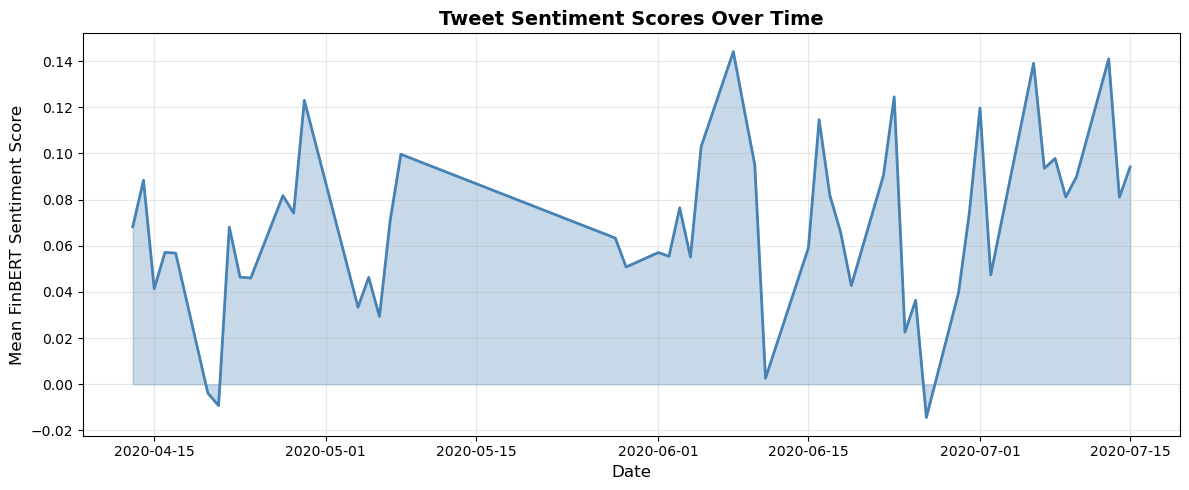

In [17]:
# convert date index to datetime for proper plotting
model_df.index = pd.to_datetime(model_df.index)

# create time series plot of sentiment scores
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(model_df.index, model_df['mean_fb_score'], linewidth=2, color='steelblue')
ax.fill_between(model_df.index, model_df['mean_fb_score'], alpha=0.3, color='steelblue')

# format axes and add labels
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Mean FinBERT Sentiment Score', fontsize=12)
ax.set_title('Tweet Sentiment Scores Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### Evaluation Table Visualizations

#### Accuracy Across Sectors

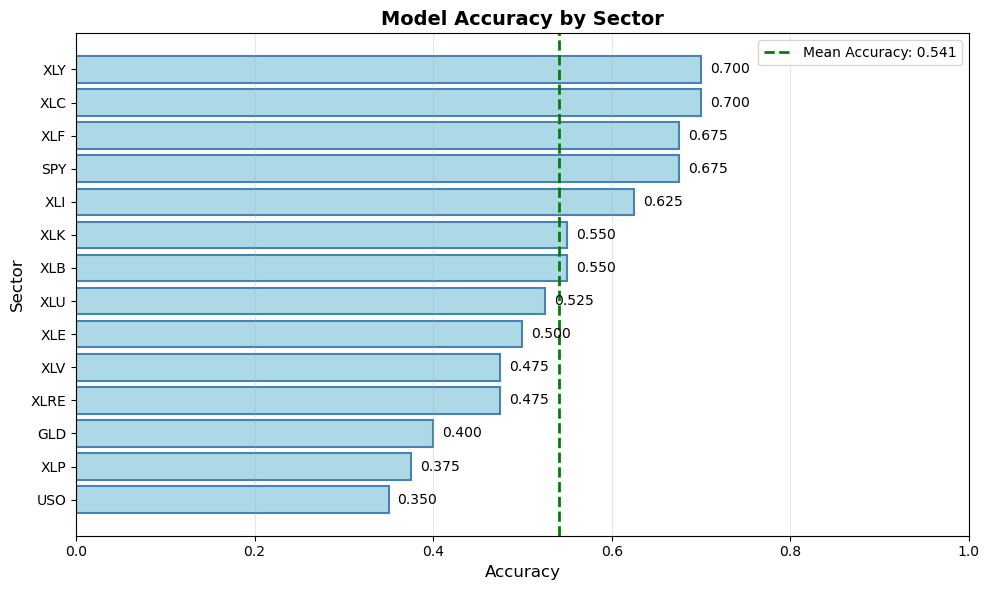

In [18]:
# sort sectors by accuracy 
sorted_df = mnlg_df.sort_values('accuracy_mean', ascending=True)

# create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sorted_df['ticker'], sorted_df['accuracy_mean'], color='lightblue', edgecolor='steelblue', linewidth=1.5)

# add accuracy value labels to each bar
for i, (ticker, accuracy) in enumerate(zip(sorted_df['ticker'], sorted_df['accuracy_mean'])):
    ax.text(accuracy + 0.01, i, f'{accuracy:.3f}', va='center', fontsize=10)

# add vertical line showing mean accuracy
mean_accuracy = mnlg_df['accuracy_mean'].mean()
ax.axvline(mean_accuracy, color='green', linestyle='--', linewidth=2, label=f'Mean Accuracy: {mean_accuracy:.3f}')

# format axes and add labels
ax.set_xlabel('Accuracy', fontsize=12)
ax.set_ylabel('Sector', fontsize=12)
ax.set_title('Model Accuracy by Sector', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

fig.tight_layout()
plt.show()

#### Confusion Matrices by Sector

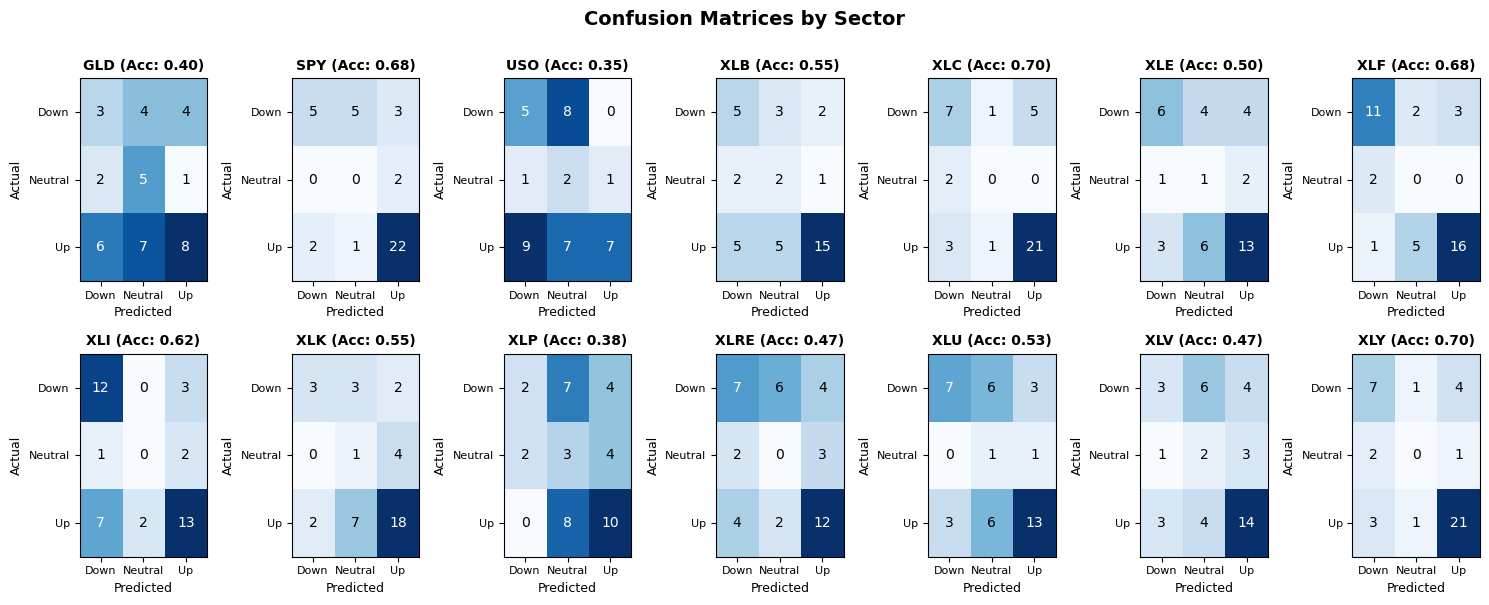

In [19]:
# extract confusion matrix columns and define class labels
cm_cols = [col for col in mnlg_df.columns if col.startswith('cm_')]
class_labels = ['Down', 'Neutral', 'Up']

# create grid of subplots 
fig, axes = plt.subplots(2, 7, figsize=(15, 6))
axes = axes.flatten()

# generate a confusion matrix heatmap for each sector
for idx, row in mnlg_df.iterrows():
    ax = axes[idx]
    
    # put the confusion matrix values into a 3x3 grid
    cm = np.array([row[col] for col in cm_cols]).reshape(3, 3)
    
    # create heatmap with blue colors
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    
    # set axis ticks and labels
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    ax.set_xticklabels(class_labels, fontsize=8)
    ax.set_yticklabels(class_labels, fontsize=8)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    
    # add count annotations to each cell
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, int(cm[i, j]), ha="center", va="center", 
                          color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=10)
    
    # add sector name and accuracy to subplot title
    ax.set_title(f'{row["ticker"]} (Acc: {row["accuracy_mean"]:.2f})', fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices by Sector', fontsize=14, fontweight='bold', y=1.00)
fig.tight_layout()
plt.show()

### Random Forest Evaluation

#### Confusion Matrices by Sector

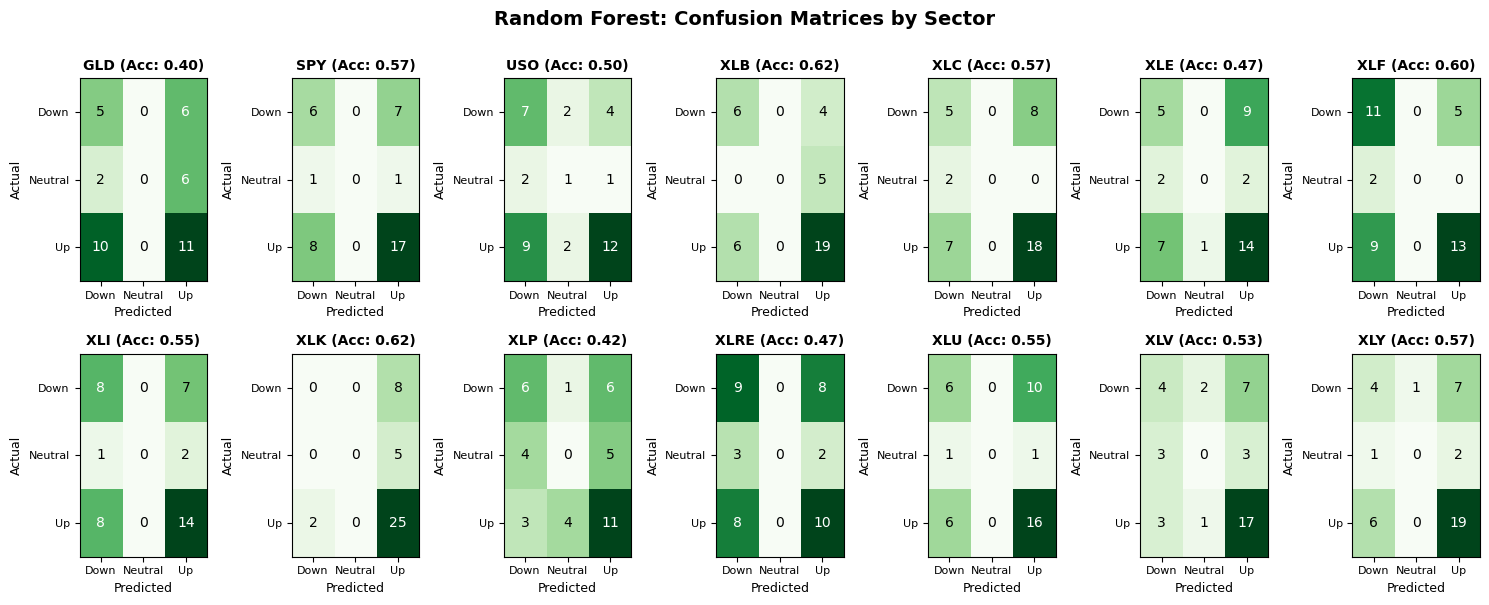

In [20]:
# extract confusion matrix columns and define class labels
cm_cols = [col for col in rf_df.columns if col.startswith('cm_')]
class_labels = ['Down', 'Neutral', 'Up']

# create grid of subplots 
fig, axes = plt.subplots(2, 7, figsize=(15, 6))
axes = axes.flatten()

# generate a confusion matrix heatmap for each sector
for idx, row in rf_df.iterrows():
    ax = axes[idx]
    
    # put the confusion matrix values into a 3x3 grid
    cm = np.array([row[col] for col in cm_cols]).reshape(3, 3)
    
    # create heatmap with green colors to differentiate from logistic regression
    im = ax.imshow(cm, cmap='Greens', aspect='auto')
    
    # set axis ticks and labels
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    ax.set_xticklabels(class_labels, fontsize=8)
    ax.set_yticklabels(class_labels, fontsize=8)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    
    # add count annotations to each cell
    for i in range(3):
        for j in range(3):
            text = ax.text(j, i, int(cm[i, j]), ha="center", va="center", 
                          color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=10)
    
    # add sector name and accuracy to subplot title
    ax.set_title(f'{row["ticker"]} (Acc: {row["accuracy_mean"]:.2f})', fontsize=10, fontweight='bold')

plt.suptitle('Random Forest: Confusion Matrices by Sector', fontsize=14, fontweight='bold', y=1.00)
fig.tight_layout()
plt.show()